In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 11.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer,Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from transformers import TFBertForMaskedLM,BertTokenizer
import re
from transformers import TFBertModel

In [ ]:
csv_file_path = "/content/drive/MyDrive/Nepali_Dataset/sentiment_analysis_nepali_final.csv"
df = pd.read_csv(csv_file_path)
print(df.head())

   Unnamed: 0                                          Sentences  Sentiment
0           0  म एक शिक्षक , शिक्षा क्षेत्रमा रमाएको मान्छे ।...          1
1           1  म सरकारी स्कूल/कलेजमा पढेर करीब १२ बर्ष भन्दा ...          1
2           2  कति राम्रो शिव मन्दिर देख्न पाइयो कुन ठाउको हो...          1
3           3  मारुनी भन्ने वितिकै सामान्य नाचनीमा आधारित कथा...          1
4           4  यो फ्लिम हेरिसकेपछी थाहा भयो कि किन दर्सकहरुले...          1


In [ ]:
emoji_dict = {
    "😀": "हाँसिरहेको अनुहार",
    "😃": "ठूलो आँखाहरू भएको हाँसिरहेको अनुहार",
    "😄": "हाँसिरहेको आँखाहरू भएको अनुहार",
    "😁": "उज्यालो हाँसिरहेको अनुहार",
    "😆": "हाँसिरहेको खुम्चिएको अनुहार",
    "😅": "पसीना आएको हाँसिरहेको अनुहार",
    "🤣": "भुइँमा लडेर हाँसिरहेको अनुहार",
    "😂": "आँसु खस्दै हाँसिरहेको अनुहार",
    "🙂": "हल्का मुस्काइरहेको अनुहार",
    "🙃": "उल्टिएको अनुहार",
    "😉": "आँखा झिम्क्याइरहेको अनुहार",
    "😊": "मुस्काइरहेको अनुहार",
    "😇": "स्वर्गदूत अनुहार",
    "🥰": "माया दर्शाउँदै मुस्काइरहेको अनुहार",
    "😍": "मन परेको आँखासहित मुस्काइरहेको अनुहार",
    "🤩": "तारा परेको अनुहार",
    "😘": "चुम्बन पठाइरहेको अनुहार",
    "😗": "चुम्बन गर्ने अनुहार",
    "😚": "आँखा बन्द गरेर चुम्बन गर्ने अनुहार",
    "😙": "मुस्काइरहेको चुम्बन गर्ने अनुहार",
    "😋": "खाना चाखिरहेको अनुहार",
    "😛": "जिब्रो देखाएको अनुहार",
    "😜": "आँखा झिम्क्याएर जिब्रो देखाएको अनुहार",
    "🤪": "मजा लिइरहेको अनुहार",
    "😝": "आँखा बन्द गरेर जिब्रो देखाएको अनुहार",
    "🤑": "पैसा माया गर्ने अनुहार",
    "🤗": "अंगालो हाल्ने अनुहार",
    "🤭": "मुख छोप्ने अनुहार",
    "🤫": "चुप लाग्न संकेत गर्ने अनुहार",
    "🤔": "सोचिरहेको अनुहार",
    "🤐": "मुख बन्द भएको अनुहार",
    "🤨": "उज्यालो उठेको भौं भएको अनुहार",
    "😐": "निष्प्रभाव अनुहार",
    "😑": "भावशून्य अनुहार",
    "😶": "बिना मुखको अनुहार",
    "😏": "अलिकति हाँसिरहेको अनुहार",
    "😒": "मन नपरेको अनुहार",
    "🙄": "आँखा घुमाएको अनुहार",
    "😬": "असंकोचित अनुहार",
    "🤥": "झूट बोल्ने अनुहार",
    "😌": "शान्त अनुहार",
    "😔": "गम्भीर अनुहार",
    "😪": "निद्रालु अनुहार",
    "🤤": "लालपुच्छ्रिएको अनुहार",
    "😴": "सुतिरहेको अनुहार",
    "😷": "मास्क लगाएको अनुहार",
    "🤒": "ताप लागेको अनुहार",
    "🤕": "टाउकोमा पट्टी बाँधिएको अनुहार",
    "🤢": "वाकवाक लागेको अनुहार",
    "🤮": "वाकवाक लागेर बान्ता गरिरहेको अनुहार",
    "🤧": "छींक आइरहेको अनुहार",
    "🥵": "गर्मी लागेको अनुहार",
    "🥶": "जाडो लागेको अनुहार",
    "🥴": "मातेको अनुहार",
    "😵": "झल्झली भएको अनुहार",
    "🤯": "मस्तिष्क विस्फोट भएको अनुहार",
    "🤠": "काउबोय टोपी लगाएको अनुहार",
    "🥳": "पार्टी गर्दै गरेको अनुहार",
    "😎": "चश्मा लगाएको मुस्काइरहेको अनुहार",
    "🤓": "पढ्न मन पराउने अनुहार",
    "🧐": "ऐनामा हेर्दै गरेको अनुहार",
    "😕": "विचलित अनुहार",
    "😟": "चिन्तित अनुहार",
    "🙁": "अलिकति उदास अनुहार",
    "☹️": "उदास अनुहार",
    "😮": "मुख खुला भएको अनुहार",
    "😯": "आश्चर्यचकित अनुहार",
    "😲": "छक्क परेको अनुहार",
    "😳": "लाज लागेको अनुहार",
    "🥺": "मायालु आँखासहितको अनुहार",
    "😦": "मुख खुला भएको खिन्न अनुहार",
    "😧": "कष्टकर अनुहार",
    "😨": "डराएको अनुहार",
    "😰": "पसीना आएको चिन्तित अनुहार",
    "😥": "दुःखी तर राहत भएको अनुहार",
    "😢": "रुँदै गरेको अनुहार",
    "😭": "जोर-जोरले रुँदै गरेको अनुहार",
    "😱": "डराएर कराउँदै गरेको अनुहार",
    "😖": "विफल अनुहार",
    "😣": "अधैर्य अनुहार",
    "😞": "निराश अनुहार",
    "😓": "पसीना आएको निराश अनुहार",
    "😩": "थकित अनुहार",
    "😫": "थाकेको अनुहार",
    "🥱": "आँघी लागेको अनुहार",
    "😤": "रिसाएको अनुहार",
    "😡": "रिसाएको अनुहार",
    "😠": "रिसाएको अनुहार",
    "🤬": "गाली गरिरहेको अनुहार",
    "😈": "सैतानी मुस्कानसहितको अनुहार",
    "👿": "रिसाएको सैतानी अनुहार",
    "💀": "खप्पर",
    "☠️": "खप्पर र हड्डी",
    "💩": "पाइल अफ पू",
    "🤡": "जोकर अनुहार",
    "👹": "दानव",
    "👺": "भूत",
    "👻": "आत्मा",
    "👽": "एलियन",
    "👾": "एलियन राक्षस",
    "🤖": "रोबोट अनुहार",
    "❤️": "रातो मन",
    "💛": "पहेंलो मन",
    "💚": "हरियो मन",
    "💙": "निलो मन",
    "💜": "बैजनी मन",
    "🖤": "कालो मन",
    "🤍": "सेतो मन",
    "💔": "टुटेको मन",
    "💋": "चुम्बन चिन्ह",
    "👍": "राम्रै छ",
    "👎": "नराम्रै छ",
    "👏": "ताली बजाउँदै",
    "🙌": "खुसी भएर हात उठाउँदै",
    "🤝": "हात मिलाउँदै",
    "🙏": "नमस्ते गर्दै",
}


In [ ]:
def preprocess_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Handle emojis
    for emoji, description in emoji_dict.items():
        text = text.replace(emoji, f" {description} ")

    # Remove stopwords
    text = ' '.join(word for word in text.split() if word.lower() not in stop_words)

    return text

In [ ]:

df = df[['Sentences', 'Sentiment']]
df['Sentiment'] = df['Sentiment'].map({-1: 0, 0: 1, 1: 2})

<ipython-input-5-938e142dbcfb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment'] = df['Sentiment'].map({-1: 0, 0: 1, 1: 2})


In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
df['Sentiment'] = label_encoder.fit_transform(df['Sentiment'])
y = to_categorical(df['Sentiment'])  # Converts to categorical for 3 classes


In [ ]:
h_model = TFBertModel.from_pretrained("NepBERTa/NepBERTa")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/534M [00:00<?, ?B/s]

Some layers from the model checkpoint at NepBERTa/NepBERTa were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at NepBERTa/NepBERTa and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("NepBERTa/NepBERTa", num_labels=3,from_tf=True)

All TF 2.0 model weights were used when initializing BertForSequenceClassification.

All the weights of BertForSequenceClassification were initialized from the TF 2.0 model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BertForSequenceClassification for predictions without further training.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("NepBERTa/NepBERTa")

vocab.txt:   0%|          | 0.00/547k [00:00<?, ?B/s]

In [ ]:
from transformers import TFBertModel
class CustomBertLayer(Layer):
    def __init__(self, bert_model):
        super(CustomBertLayer, self).__init__()
        self.bert_model = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        bert_output = self.bert_model(input_ids=input_ids, attention_mask=attention_mask)
        return bert_output.last_hidden_state

In [ ]:
def extract_cls_token(bert_outputs):
    hidden_states = bert_outputs
    return hidden_states[:, 0, :]


In [ ]:
def build_model2(bert_model, num_classes=3):
    input_ids = Input(shape=(100,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(100,), dtype=tf.int32, name="attention_mask")
    bert_output = CustomBertLayer(bert_model)([input_ids, attention_mask])
    cls_token_output = Lambda(extract_cls_token)(bert_output)
    output = Dense(3, activation='softmax')(cls_token_output)
    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

In [ ]:
model2=build_model2(h_model)

In [ ]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
texts_train, texts_val, y_train, y_val = train_test_split(df['Sentences'], y, test_size=0.3, random_state=42)


In [ ]:
train_encodings = tokenizer(list(texts_train), truncation=True, padding=True, max_length=100)
val_encodings = tokenizer(list(texts_val), truncation=True, padding=True, max_length=100)

In [ ]:
train_input_ids = train_encodings["input_ids"]
train_attention_mask = train_encodings["attention_mask"]

In [ ]:
val_input_ids = val_encodings["input_ids"]
val_attention_mask = val_encodings["attention_mask"]

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_input_ids = pad_sequences(train_input_ids, maxlen=100, padding='post', truncating='post')
val_input_ids = pad_sequences(val_input_ids, maxlen=100, padding='post', truncating='post')

train_attention_mask = pad_sequences(train_attention_mask, maxlen=100, padding='post', truncating='post')
val_attention_mask = pad_sequences(val_attention_mask, maxlen=100, padding='post', truncating='post')


In [ ]:
history_h = model2.fit(
    [train_input_ids, train_attention_mask],
    y_train,
    validation_data=(
        [val_input_ids, val_attention_mask],
        y_val
    ),
    epochs=10,
    batch_size=128
)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.5510 - loss: 0.9293 - val_accuracy: 0.6519 - val_loss: 0.7970
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.6509 - loss: 0.7963 - val_accuracy: 0.6610 - val_loss: 0.7751
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6613 - loss: 0.7816 - val_accuracy: 0.6708 - val_loss: 0.7636
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 234s 924ms/step - accuracy: 0.6705 - loss: 0.7584 - val_accuracy: 0.6710 - val_loss: 0.7620
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.6758 - loss: 0.7572 - val_accuracy: 0.6684 - val_loss: 0.7585
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6679 - loss: 0.7568 - val_accuracy: 0.6777 - val_loss: 0.7506
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 234s 923ms/step - accuracy: 0.6767 - loss: 0.7455 - val_accuracy: 0.6788 - val_loss: 0.7481
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 922ms/step - accuracy: 0.6816 - loss: 0.7438 -

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model2.predict([val_input_ids, val_attention_mask])
y_pred_labels = y_pred.argmax(axis=-1)
y_val_labels = y_val.argmax(axis=-1)

accuracy = accuracy_score(y_val_labels, y_pred_labels)
precision = precision_score(y_val_labels, y_pred_labels, average='weighted')
recall = recall_score(y_val_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_val_labels, y_pred_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

336/336 ━━━━━━━━━━━━━━━━━━━━ 75s 203ms/step
Accuracy: 0.6797
Precision: 0.6608
Recall: 0.6797
F1-Score: 0.6607


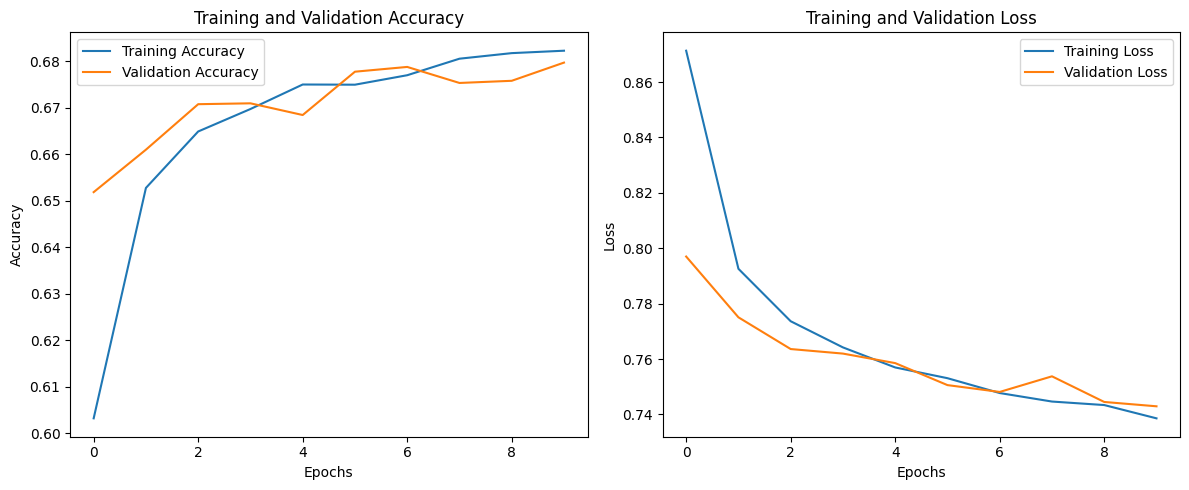

In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_h)

In [ ]:
history_h = model2.fit(
    [train_input_ids, train_attention_mask],
    y_train,
    validation_data=(
        [val_input_ids, val_attention_mask],
        y_val
    ),
    epochs=25,
    batch_size=128
)

Epoch 1/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6863 - loss: 0.7327 - val_accuracy: 0.6780 - val_loss: 0.7436
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 234s 923ms/step - accuracy: 0.6847 - loss: 0.7385 - val_accuracy: 0.6805 - val_loss: 0.7416
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 922ms/step - accuracy: 0.6850 - loss: 0.7316 - val_accuracy: 0.6790 - val_loss: 0.7392
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.6819 - loss: 0.7373 - val_accuracy: 0.6803 - val_loss: 0.7374
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6875 - loss: 0.7343 - val_accuracy: 0.6796 - val_loss: 0.7384
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6864 - loss: 0.7270 - val_accuracy: 0.6829 - val_loss: 0.7399
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6910 - loss: 0.7243 - val_accuracy: 0.6802 - val_loss: 0.7407
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 234s 922ms/step - accuracy: 0.6870 - loss: 0.7264 -

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model2.predict([val_input_ids, val_attention_mask])
y_pred_labels = y_pred.argmax(axis=-1)
y_val_labels = y_val.argmax(axis=-1)

accuracy = accuracy_score(y_val_labels, y_pred_labels)
precision = precision_score(y_val_labels, y_pred_labels, average='weighted')
recall = recall_score(y_val_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_val_labels, y_pred_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

336/336 ━━━━━━━━━━━━━━━━━━━━ 60s 178ms/step
Accuracy: 0.6778
Precision: 0.6657
Recall: 0.6778
F1-Score: 0.6555


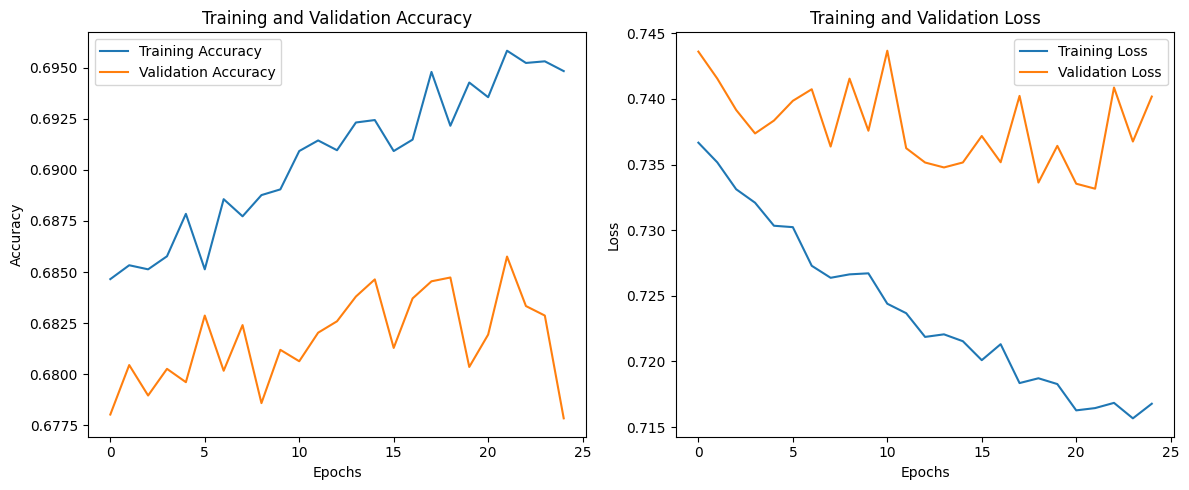

In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_h)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_model2(bert_model, num_classes=3):
    input_ids = Input(shape=(100,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(100,), dtype=tf.int32, name="attention_mask")
    bert_output = CustomBertLayer(bert_model)([input_ids, attention_mask])
    cls_token_output = Lambda(extract_cls_token)(bert_output)

    # Add Dropout to prevent overfitting
    x = tf.keras.layers.Dropout(0.3)(cls_token_output)

    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=[input_ids, attention_mask], outputs=output)

    # Compile with smaller learning rate
    optimizer = Adam(learning_rate=2e-5)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [ ]:
model2 = build_model2(h_model)

In [ ]:
# Callbacks for fine-tuning
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]


In [ ]:
history_h = model2.fit(
    [train_input_ids, train_attention_mask],
    y_train,
    validation_data=([val_input_ids, val_attention_mask], y_val),
    epochs=15,  # Increase epochs
    batch_size=64,  # Smaller batch size if OOM occurs
    callbacks=callbacks
)

Epoch 1/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 229s 584ms/step - accuracy: 0.3696 - loss: 1.1782 - val_accuracy: 0.4570 - val_loss: 1.0257
Epoch 2/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 251s 556ms/step - accuracy: 0.4300 - loss: 1.1014 - val_accuracy: 0.5084 - val_loss: 0.9920
Epoch 3/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 262s 556ms/step - accuracy: 0.4692 - loss: 1.0562 - val_accuracy: 0.5419 - val_loss: 0.9643
Epoch 4/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 237s 493ms/step - accuracy: 0.4898 - loss: 1.0306 - val_accuracy: 0.5668 - val_loss: 0.9418
Epoch 5/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 226s 555ms/step - accuracy: 0.5108 - loss: 1.0060 - val_accuracy: 0.5839 - val_loss: 0.9233
Epoch 6/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 238s 494ms/step - accuracy: 0.5374 - loss: 0.9788 - val_accuracy: 0.5951 - val_loss: 0.9078
Epoch 7/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 201s 492ms/step - accuracy: 0.5428 - loss: 0.9698 - val_accuracy: 0.6024 - val_loss: 0.8948
Epoch 8/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 226s 555ms/step - accuracy: 0.5563 -

In [ ]:
history_h = model2.fit(
    [train_input_ids, train_attention_mask],
    y_train,
    validation_data=([val_input_ids, val_attention_mask], y_val),
    epochs=20,  # Increase epochs
    batch_size=128,  # Smaller batch size if OOM occurs
    callbacks=callbacks
)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.6039 - loss: 0.8833 - val_accuracy: 0.6343 - val_loss: 0.8360
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.6020 - loss: 0.8929 - val_accuracy: 0.6352 - val_loss: 0.8340
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 188s 961ms/step - accuracy: 0.5973 - loss: 0.8889 - val_accuracy: 0.6357 - val_loss: 0.8319
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 961ms/step - accuracy: 0.6122 - loss: 0.8754 - val_accuracy: 0.6366 - val_loss: 0.8299
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 961ms/step - accuracy: 0.6064 - loss: 0.8787 - val_accuracy: 0.6383 - val_loss: 0.8279
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 961ms/step - accuracy: 0.6065 - loss: 0.8726 - val_accuracy: 0.6385 - val_loss: 0.8260
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 961ms/step - accuracy: 0.6018 - loss: 0.8827 - val_accuracy: 0.6396 - val_loss: 0.8242
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 961ms/step - accuracy: 0.6053 - loss:

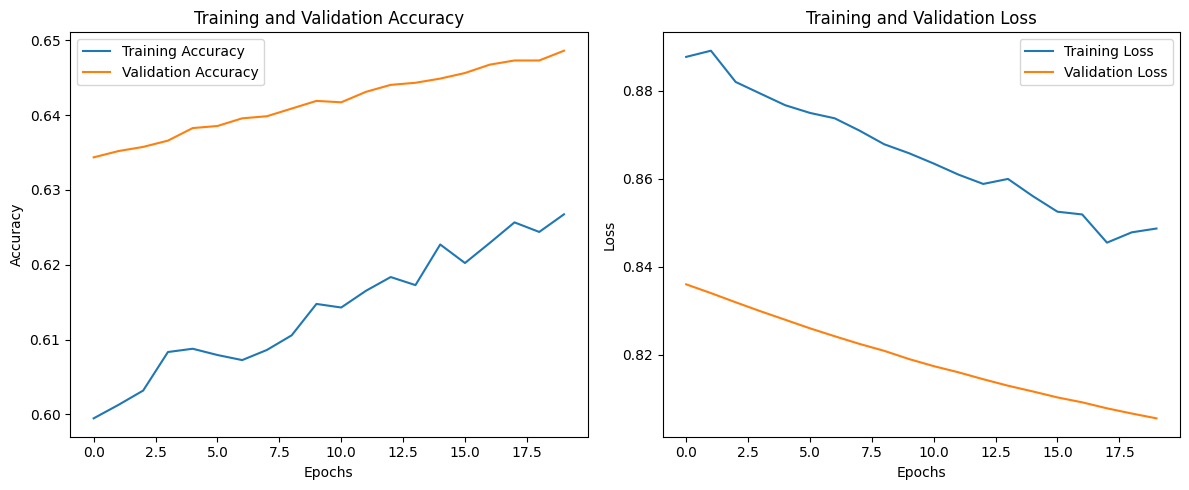

In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_h)